<a href="https://colab.research.google.com/github/baebiblue/Energy-Consumption-Analysis/blob/main/Energy_Consumption_Anlysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
print(f"Pandas version: {pd.__version__}")


Pandas version: 2.2.2


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้กราฟแสดงผลสวยงาม
%matplotlib inline
sns.set(style="whitegrid")


In [14]:
from google.colab import drive
drive.mount('/content/drive')

# ตัวอย่างการอ่านไฟล์ (เปลี่ยน Path ตามจริงของคุณ)
# df = pd.read_csv('/content/drive/MyDrive/project_ndata.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### วิธีตรวจสอบไฟล์ใน Google Drive ของคุณ:
ลองรันโค้ดด้านล่างนี้เพื่อแสดงไฟล์ 50 อันดับแรกใน Google Drive ของคุณ เพื่อช่วยคุณหา Path ที่ถูกต้อง หากไฟล์ของคุณอยู่ในโฟลเดอร์ย่อย คุณอาจต้องปรับ `path` ให้ตรงกับโฟลเดอร์นั้นๆ ครับ

In [17]:
import kagglehub
path = kagglehub.dataset_download("mrsimple07/energy-consumption-prediction")

Using Colab cache for faster access to the 'energy-consumption-prediction' dataset.


In [19]:
import os
import pandas as pd

# 1. ค้นหาตำแหน่งไฟล์ที่เพิ่งโหลดมา
# ตัวแปร path คือสิ่งที่เราได้มาจากขั้นตอนก่อนหน้า
file_name = os.listdir(path)[0]
full_path = os.path.join(path, file_name)

# 2. อ่านไฟล์ csv เข้ามา
df = pd.read_csv(full_path)

# 3. โชว์ผลลัพธ์ 100 แถวแรก
df.head()


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [20]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1U_hJErRh_mwMA6-D_1trrR2ld5goHBKx1oEfQjQHSRE/edit#gid=0


In [22]:
# ดูประเภทข้อมูลและเช็กค่าว่าง
df.info()

# ดูสถิติพื้นฐาน (ค่าเฉลี่ย, ค่าสูงสุด-ต่ำสุด ของอุณหภูมิและการใช้ไฟ)
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [23]:
# 1. แปลง HVACUsage และ LightingUsage (On=1, Off=0)
df['HVACUsage'] = df['HVACUsage'].map({'On': 1, 'Off': 0})
df['LightingUsage'] = df['LightingUsage'].map({'On': 1, 'Off': 0})

# 2. แปลง Holiday (Yes=1, No=0)
df['Holiday'] = df['Holiday'].map({'Yes': 1, 'No': 0})

# 3. แปลง Timestamp ให้เป็นรูปแบบวันที่จริง ๆ (เผื่อใช้ดูเทรนด์รายชั่วโมง)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# ดูผลลัพธ์ว่าประเภทข้อมูล (Dtype) เปลี่ยนหรือยัง
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1000 non-null   datetime64[ns]
 1   Temperature        1000 non-null   float64       
 2   Humidity           1000 non-null   float64       
 3   SquareFootage      1000 non-null   float64       
 4   Occupancy          1000 non-null   int64         
 5   HVACUsage          1000 non-null   int64         
 6   LightingUsage      1000 non-null   int64         
 7   RenewableEnergy    1000 non-null   float64       
 8   DayOfWeek          1000 non-null   object        
 9   Holiday            1000 non-null   int64         
 10  EnergyConsumption  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(4), object(1)
memory usage: 86.1+ KB


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. เลือกตัวแปรที่จะใช้ทำนาย (Features) และตัวแปรที่ต้องการผลลัพธ์ (Target)
# เราจะยังไม่ใช้ DayOfWeek และ Timestamp ในรอบแรกนี้
X = df[['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday']]
y = df['EnergyConsumption']

# 2. แบ่งข้อมูลเป็น 2 ชุด: ชุดฝึกสอน (Train) 80% และชุดทดสอบ (Test) 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างและฝึกสอนโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# 4. ทดลองทำนายผล
y_pred = model.predict(X_test)

# 5. วัดผลแม่นยำ
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")


R-squared Score: 0.5986


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. สร้างโมเดลแบบ Random Forest (ใช้ X_train, y_train ชุดเดิม)
# เราใช้ random_state เพื่อให้ผลลัพธ์คงที่
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. ทดลองทำนายผลกับชุดทดสอบ (X_test)
y_pred_rf = rf_model.predict(X_test)

# 3. วัดผลแม่นยำเทียบกับโมเดลเดิม
print(f"Old (Linear Regression) R²: 0.5986")
print(f"New (Random Forest) R²: {r2_score(y_test, y_pred_rf):.4f}")


Old (Linear Regression) R²: 0.5986
New (Random Forest) R²: 0.5397


In [26]:
# 1. ดึงข้อมูลชั่วโมง (Hour) ออกมาจาก Timestamp
df['Hour'] = df['Timestamp'].dt.hour

# 2. สร้างตัวแปร "เป็นช่วงเย็นหรือไม่" (Peak Hour)
# สมมติว่าเป็นช่วง 17:00 - 22:00 ที่คนใช้ไฟเยอะ
df['IsPeak'] = df['Hour'].apply(lambda x: 1 if 17 <= x <= 22 else 0)

# 3. อัปเดตตัวแปร X ใหม่ โดยเพิ่ม Hour และ IsPeak เข้าไป
X_new = df[['Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
            'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'Hour', 'IsPeak']]
y = df['EnergyConsumption']

# 4. แบ่งข้อมูลและรัน Linear Regression อีกรอบ
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y, test_size=0.2, random_state=42)
model_final = LinearRegression()
model_final.fit(X_train_n, y_train_n)

print(f"Final R-squared Score: {r2_score(y_test_n, model_final.predict(X_test_n)):.4f}")


Final R-squared Score: 0.5971


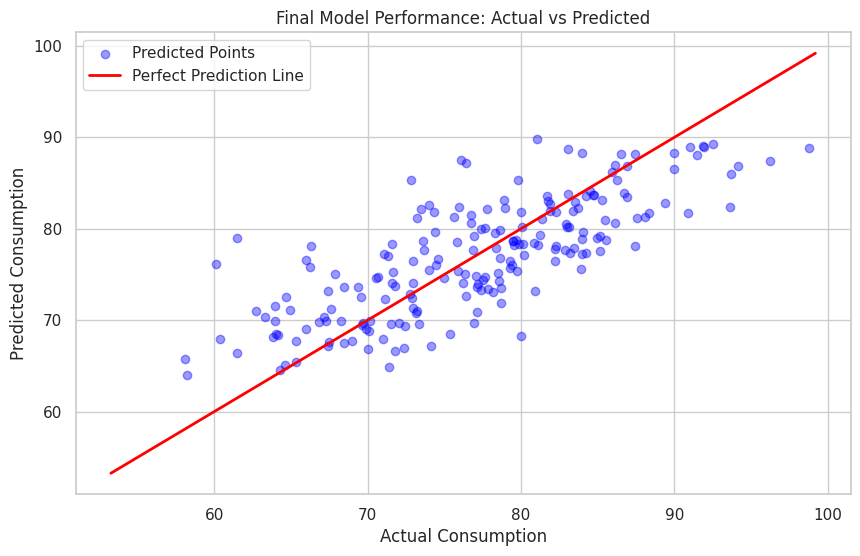

In [27]:
import matplotlib.pyplot as plt

y_pred_final = model_final.predict(X_test_n)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_n, y_pred_final, color='blue', alpha=0.4, label='Predicted Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Consumption')
plt.ylabel('Predicted Consumption')
plt.title('Final Model Performance: Actual vs Predicted')
plt.legend()
plt.show()


Summary & Business Recommendations

1.	Model Reliability: ด้วยค่า R^2 \approx 0.60 โมเดลนี้สามารถนำไปใช้เป็น "ระบบแจ้งเตือนล่วงหน้า" (Early Warning) เมื่อมีการใช้พลังงานผิดปกติได้
2.	Cost Management: การที่อุณหภูมิ (Temperature) มีผลสูง แสดงว่า Galaxy Data Center สามารถลดต้นทุนได้โดยการเพิ่มประสิทธิภาพระบบฉนวน หรือปรับตั้งค่า HVAC ให้ยืดหยุ่นตามอุณหภูมิภายนอก
3.	Future Work: ในอนาคตสามารถเพิ่มข้อมูล "ราคาค่าไฟรายชั่วโมง" (TOU Tariff) เพื่อคำนวณเป็นตัวเงิน (Baht) และหาจุดที่คุ้มค่าที่สุดในการสลับไปใช้พลังงานหมุนเวียน (Renewable Energy)